# P14. Seismic Q: Earth's Attenuation Without a Viscosity

Seismic Earth models give loss as quality factors, not viscosities. PREM tabulates the shear quality factor $Q_\mu$ (600 in the crust and lid, 80 in the low-velocity zone, 143 down to 670 km, 312 in the lower mantle, 84.6 in the inner core) and the bulk quality factor $Q_\kappa$, at a 1 s reference period. TidalPy can use these directly, without inverting for a viscosity or assuming a viscoelastic model.

- The `seismic_q` rheology builds a complex modulus from a static modulus and a quality factor measured at a reference frequency.
- A world built from a radial data file with `q_provided = true` gives each solid layer this rheology, using the file's `q_mu` and `q_kappa` columns. The reference frequency and the frequency scaling of $Q$ are set in the world's TOML.
- The bundled `PREM.csv` includes PREM's quality factors, which the bundled `earth_prem_q` world uses.

This notebook:

1. Shows the model: the loss and the dispersion it implies from 1 s to tidal periods.
2. Plots PREM's quality factors.
3. Compares PREM with and without its attenuation, at 1 s and at tidal periods.
4. Finds how $Q$ must scale with frequency for PREM to reproduce Earth's measured M2 body-tide lag.
5. Sets the scaling layer by layer.

In [1]:
%matplotlib inline
import copy
import math

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Rheology import seismic_q
from TidalPy.Structures import build_world
from TidalPy.Structures.configs import data_file, worldpack

HOUR, DAY, YEAR = 3600.0, 86400.0, 365.25 * 86400.0
PREM_REFERENCE = 2.0 * math.pi                     # PREM's 1 s reference period [rad/s]
M2 = 2.0 * math.pi / (12.4206012 * HOUR)           # Principal lunar semidiurnal tide [rad/s]

## The Model

`seismic_q` reads its viscosity input as $Q_\mathrm{ref}$, the quality factor at the reference frequency $\omega_\mathrm{ref}$ (where the modulus $\mu$ was also measured). With $s = \omega_\mathrm{ref}/\omega$ and an exponent $a$ in $[0, 1)$:

$$Q(\omega) = Q_\mathrm{ref}\,s^{-a}, \qquad \mathrm{Re}[\mu^{*}] = \frac{\mu}{1 + D(s)/Q_\mathrm{ref}}, \qquad \mathrm{Im}[\mu^{*}] = \frac{\mathrm{Re}[\mu^{*}]}{Q(\omega)},$$

$$D(s) = \cot\frac{\pi a}{2}\left(s^{a} - 1\right) \;\to\; \frac{2}{\pi}\ln s \quad (a = 0).$$

The loss comes from the data. $D$ is the dispersion that causality requires, since a dissipating material cannot have the same modulus at every frequency. A constant $Q$ ($a = 0$) softens the modulus logarithmically toward long periods (Kanamori and Anderson 1977). A $Q$ that falls as $\omega^{a}$ toward long periods softens it faster, like an absorption band (Wahr and Bergen 1986). Below, $Q_\mathrm{ref} = 143$ (PREM's upper mantle), from 1 s to 3 years.

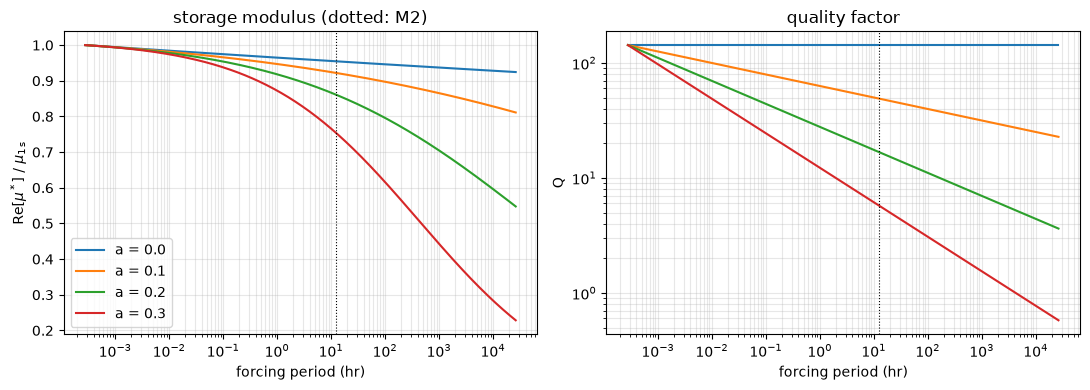

At M2, relative to 1 s:
  a = 0.0:  Re[mu*] / mu = 0.9545   Q =  143.0
  a = 0.1:  Re[mu*] / mu = 0.9219   Q =   49.0
  a = 0.2:  Re[mu*] / mu = 0.8608   Q =   16.8
  a = 0.3:  Re[mu*] / mu = 0.7535   Q =    5.8
At 3 years with a = 0.3: Q = 0.58


In [2]:
q_ref = 143.0
periods = np.logspace(0.0, math.log10(3.0 * YEAR), 300)
frequencies = 2.0 * math.pi / periods
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for exponent in (0.0, 0.1, 0.2, 0.3):
    modulus = seismic_q(1.0, q_ref, frequencies, q_frequency_exponent=exponent)
    axes[0].semilogx(periods / HOUR, modulus.real, label=f"a = {exponent}")
    axes[1].loglog(periods / HOUR, modulus.real / modulus.imag, label=f"a = {exponent}")
for ax in axes:
    ax.axvline(12.4206012, color="k", lw=0.8, ls=":")
    ax.set_xlabel("forcing period (hr)")
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel(r"Re[$\mu^*$] / $\mu_\mathrm{1\,s}$")
axes[1].set_ylabel("Q")
axes[0].legend()
axes[0].set_title("storage modulus (dotted: M2)")
axes[1].set_title("quality factor")
plt.tight_layout()
plt.show()

print("At M2, relative to 1 s:")
for exponent in (0.0, 0.1, 0.2, 0.3):
    modulus = seismic_q(1.0, q_ref, M2, q_frequency_exponent=exponent)
    print(f"  a = {exponent}:  Re[mu*] / mu = {modulus.real:.4f}   Q = {modulus.real / modulus.imag:6.1f}")
modulus = seismic_q(1.0, q_ref, frequencies[-1], q_frequency_exponent=0.3)
print(f"At 3 years with a = 0.3: Q = {modulus.real / modulus.imag:.2f}")

Even at $a = 0$ (constant $Q = 143$), the modulus at M2 is 4.6% softer than PREM's 1 s value. This is the anelastic correction geodesists apply to Earth's $k_2$. Any further softening, and how far $Q$ falls, depends entirely on $a$. The data do not constrain $a$, so it is the model's one real assumption. A single power law also only holds over a limited band: carried to 3 years, $a = 0.3$ lowers $Q$ from 143 to below 1.

## PREM's Quality Factors

The bundled `PREM.csv` has `q_mu` and `q_kappa` columns beside the radius, density, and velocities. The loader reads them when present, but a world uses them only with `q_provided = true`, so `earth_prem` (built from the same file) stays elastic. $Q_\mu = 0$ marks the liquid outer core. $Q_\kappa$ is 57823 everywhere except the inner core (1327.7), so bulk loss is negligible.

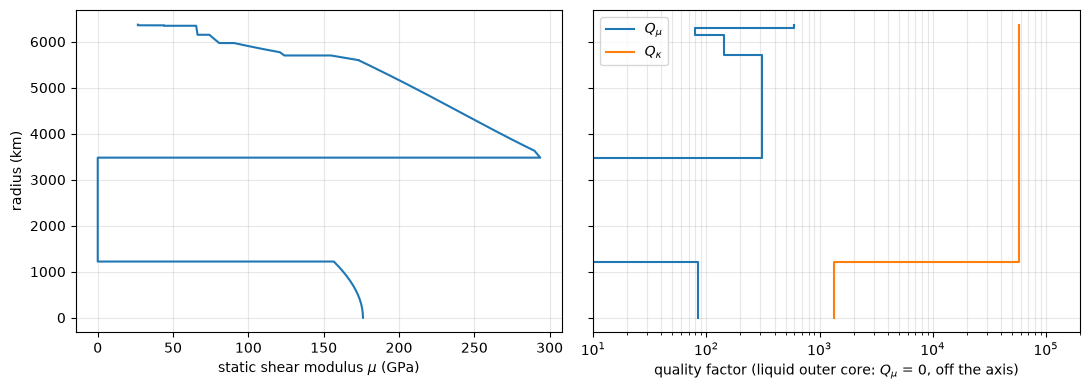

      0.0 to  1221.5 km:  Q_mu =   84.6
   1221.5 to  3480.0 km:  Q_mu =    0.0
   3480.0 to  5701.0 km:  Q_mu =  312.0
   5701.0 to  6151.0 km:  Q_mu =  143.0
   6151.0 to  6291.0 km:  Q_mu =   80.0
   6291.0 to  6371.0 km:  Q_mu =  600.0


In [3]:
prem = data_file.load_radial_data(worldpack.resolve_data_file("PREM.csv"))
radius_km = prem["radius_m"] / 1.0e3
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].plot(prem["shear_modulus_pa"] / 1.0e9, radius_km)
axes[0].set_xlabel(r"static shear modulus $\mu$ (GPa)")
axes[1].plot(prem["shear_q"], radius_km, label=r"$Q_\mu$")
axes[1].set_xscale("log")
axes[1].set_xlim(10.0, 2.0e5)
axes[1].plot(prem["bulk_q"], radius_km, label=r"$Q_\kappa$")
axes[1].set_xlabel("quality factor (liquid outer core: $Q_\\mu$ = 0, off the axis)")
axes[0].set_ylabel("radius (km)")
axes[1].legend()
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

changes = np.flatnonzero(np.diff(prem["shear_q"]) != 0.0) + 1
for start, stop in zip(np.concatenate(([0], changes)), np.concatenate((changes, [radius_km.size]))):
    print(f"  {radius_km[start]:7.1f} to {radius_km[stop - 1]:7.1f} km:  Q_mu = {prem['shear_q'][start]:6.1f}")

## PREM With Its Own Attenuation

`earth_prem_q` is `earth_prem` with three more keys. Every solid layer then uses the `seismic_q` rheology, with its quality factors stored in its viscosity arrays, where `seismic_q` reads them:

```toml
data_file = "PREM.csv"
q_provided = true                                  # use the profile's q_mu and q_kappa columns
q_reference_frequency_rad_s = 6.283185307179586    # 2 pi rad/s: PREM's 1 s reference period
q_frequency_exponent = 0.0                         # the seismic Q at every frequency
```

In [4]:
elastic = build_world("earth_prem")
attenuating = build_world("earth_prem_q")
for world in (elastic, attenuating):
    world.solve_eos(raise_on_fail=True)

print({key: value for key, value in attenuating.portable_config.items() if key.startswith("q_")})
live = attenuating.get_config_dict()["layers"]
for layer, (name, table) in zip(attenuating, live.items()):
    print(f"  {name}: liquid = {layer.is_liquid!s:5s}  shear_rheology = {table.get('shear_rheology')}")


def k2(world, frequency):
    "k2 at one forcing frequency [rad s-1]. The world then reports its lag as love_lag_k [rad] and Q as love_q_k."
    world.solve_love_numbers(frequency=frequency, degree_l=2, raise_on_fail=True)
    return world.love_number_k


print(f"\n{'forcing':>22s} {'elastic k2':>11s} {'attenuating k2':>22s} {'lag [deg]':>10s}")
for label, period in (("1 s (reference)", 1.0), ("M2, 12.42 h", 12.4206012 * HOUR), ("K1, 23.93 h", 23.9345 * HOUR),
                      ("Mf, 13.66 d", 13.6608 * DAY), ("Chandler, 433 d", 433.0 * DAY)):
    frequency = 2.0 * math.pi / period
    k_elastic, k_attenuating = k2(elastic, frequency), k2(attenuating, frequency)
    print(f"{label:>22s} {k_elastic.real:11.5f} {k_attenuating.real:10.5f} {k_attenuating.imag:+.2e}i "
          f"{math.degrees(attenuating.love_lag_k):10.4f}")

{'q_provided': True, 'q_reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_0: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_1: liquid = True   shear_rheology = None
  layer_2: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_3: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_4: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_5: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_6: liquid = False  shear_rheology = {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exp

At 1 s the attenuating $k_2$ has the elastic real part, since PREM's moduli are its 1 s moduli, plus a small loss. At longer periods the dispersion softens the mantle, and $k_2$ grows from 0.298 to 0.302 at M2 and 0.305 at the Chandler period. With $a = 0$ the lag hardly changes with period, because $Q$ does not.

## How Must Q Scale With Frequency?

Ray, Eanes, and Lemoine (2001) measured the lag of Earth's M2 body tide from satellite tracking and altimetry as $0.20^\circ \pm 0.05^\circ$, an effective $Q$ near 280. PREM's $Q$ carried unchanged to 12 hours ($a = 0$) gives $0.116^\circ$, a little over half of that. The sweep below finds the exponent PREM needs.

M2 lag at a = 0: 0.116 deg (Q of k2 495)
a matching the measured lag 0.20 deg: 0.051 (0.15 to 0.25 deg: a = 0.024 to 0.072)


  with PREM's Q taken at 200 s instead of 1 s: a = 0.101
  with PREM's Q taken at 1000 s instead of 1 s: a = 0.143


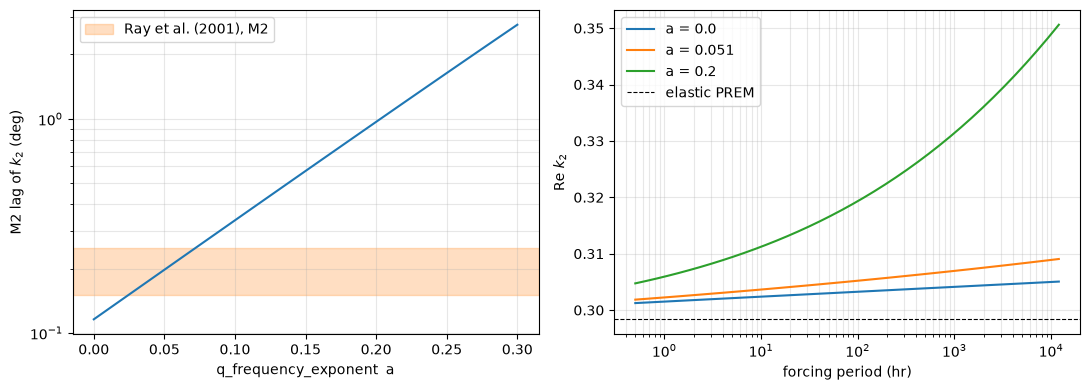

In [5]:
base = copy.deepcopy(attenuating.portable_config)


def prem_q(exponent, reference_period=1.0):
    "earth_prem_q with a Q frequency exponent, PREM's Q and moduli taken to hold at the reference period [s]."
    world = build_world(dict(base, q_frequency_exponent=float(exponent),
                             q_reference_frequency_rad_s=2.0 * math.pi / reference_period))
    world.solve_eos(raise_on_fail=True)
    return world


def m2_lag(world):
    "The M2 lag of k2 [deg]."
    k2(world, M2)
    return math.degrees(world.love_lag_k)


exponents = np.linspace(0.0, 0.3, 31)
lags = np.array([m2_lag(prem_q(exponent)) for exponent in exponents])
matched = np.interp([0.15, 0.20, 0.25], lags, exponents)
constant_q = prem_q(0.0)
k2(constant_q, M2)
print(f"M2 lag at a = 0: {lags[0]:.3f} deg (Q of k2 {constant_q.love_q_k:.0f})")
print(f"a matching the measured lag 0.20 deg: {matched[1]:.3f} "
      f"(0.15 to 0.25 deg: a = {matched[0]:.3f} to {matched[2]:.3f})")
for reference_period in (200.0, 1000.0):
    reference_lags = np.array([m2_lag(prem_q(exponent, reference_period)) for exponent in exponents])
    print(f"  with PREM's Q taken at {reference_period:.0f} s instead of 1 s: a = "
          f"{np.interp(0.20, reference_lags, exponents):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(exponents, lags)
axes[0].axhspan(0.15, 0.25, color="C1", alpha=0.25, label="Ray et al. (2001), M2")
axes[0].set_xlabel("q_frequency_exponent  a")
axes[0].set_ylabel("M2 lag of $k_2$ (deg)")
axes[0].set_yscale("log")
axes[0].legend()
periods = np.logspace(math.log10(0.5 * HOUR), math.log10(500.0 * DAY), 40)
for exponent in (0.0, round(float(matched[1]), 3), 0.2):
    loves = prem_q(exponent).calc_love_numbers(2.0 * math.pi / periods, degree_l=2)["k"]
    axes[1].semilogx(periods / HOUR, loves.real, label=f"a = {exponent}")
elastic_k2 = k2(elastic, M2).real
axes[1].axhline(elastic_k2, color="k", lw=0.8, ls="--", label="elastic PREM")
axes[1].set_xlabel("forcing period (hr)")
axes[1].set_ylabel("Re $k_2$")
axes[1].legend()
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

An exponent near 0.05 reproduces the measured lag. That is below the 0.1 to 0.3 of laboratory and geodetic estimates for the mantle, because the power law here starts at PREM's 1 s reference period and runs over four and a half decades of frequency to M2, so even a small exponent lowers $Q$ a lot. Taking PREM's $Q$ (and moduli) to hold out to 200 s instead, as some anelastic Earth models quote it, the matching exponent is 0.10, and from 1000 s it is 0.14. Take the match as illustrative:

- PREM's $Q$ is a one-dimensional average, while the measured lag belongs to the real, laterally varying Earth after an ocean-tide correction.
- A single exponent across several decades of frequency is itself an assumption.
- The reference frequency (`q_reference_frequency_rad_s`) sets where the extrapolation starts, and with it the exponent a measured lag implies.

## Layer by Layer

The world's two settings seed every solid layer's `seismic_q` table, and a layer table that names `seismic_q` overrides them for that layer. Below, the mantle's $Q$ falls with $a = 0.2$ (one table refines all ten mantle and crust layers PREM's discontinuities split it into, through `radius_range_m`), the inner core keeps its seismic $Q$, and the mantle's bulk response is elastic (ignoring $Q_\kappa$). A layer table may not name another rheology, give its material a viscosity law or a preset, or (for a solid layer) turn on melting or convection cooling. Each would either replace the quality factors or read them as a viscosity, so the build refuses it.

In [6]:
config = copy.deepcopy(base)
config["layers"] = {
    "mantle": {"radius_range_m": [3480.0e3, 6371.0e3],   # every detected layer from the core-mantle boundary up
               "shear_rheology": {"model": "seismic_q", "q_frequency_exponent": 0.2},
               "bulk_rheology": {"model": "elastic"}},
}
layered = build_world(config)
layered.solve_eos(raise_on_fail=True)
for name, table in layered.get_config_dict()["layers"].items():
    print(f"  {name}: shear {table.get('shear_rheology')}  bulk {table.get('bulk_rheology')}")
print(f"M2 k2 = {k2(layered, M2):.5f}")

try:
    build_world(dict(base, layers={"mantle": {"radius_range_m": [3480.0e3, 6371.0e3],
                                               "shear_rheology": {"model": "maxwell"}}}))
except ValueError as error:
    print("\nRefused:", error)

  layer_0: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}  bulk {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.0}
  layer_1: shear None  bulk None
  mantle_0: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
  mantle_1: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
  mantle_2: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
  mantle_3: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
  mantle_4: shear {'model': 'seismic_q', 'reference_frequency_rad_s': 6.283185307179586, 'q_frequency_exponent': 0.2}  bulk {'model': 'elastic'}
  mantle_5: shear {

## Notes

- **Where $Q$ is stored.** A layer's quality factors are stored in its viscosity arrays, so its `get_shear_viscosity` returns $Q$, not a viscosity. The `seismic_q` rheology reads that slot as $Q$ on any layer, so only attach it where the slot holds $Q$.
- **Zero frequency** is treated as no forcing: the static modulus with no loss. A constant-$Q$ lag does not shrink toward zero forcing frequency as a viscous one does, so near synchronous rotation a torque calculated from it jumps sign rather than passing through zero. Heating is unaffected, since it scales with the frequency.
- **Bulk loss** comes from `q_kappa` when the profile provides it. A layer table can set an `elastic` bulk rheology to ignore it.
- **Stale data copy.** A data file copied into the TidalPy data directory by an older install is used ahead of the packaged one. A pre-Q copy of `PREM.csv` there makes `earth_prem_q` fail with a message naming the file. Delete the copy, or call `TidalPy.Structures.install_worldpack(force=True)`.

### References

- Dziewonski, A. M., and Anderson, D. L. (1981). Preliminary reference Earth model. *Physics of the Earth and Planetary Interiors*, 25, 297-356.
- Kanamori, H., and Anderson, D. L. (1977). Importance of physical dispersion in surface wave and free oscillation problems: Review. *Reviews of Geophysics*, 15, 105-112.
- Wahr, J., and Bergen, Z. (1986). The effects of mantle anelasticity on nutations, earth tides, and tidal variations in rotation rate. *Geophysical Journal of the Royal Astronomical Society*, 87, 633-668.
- Ray, R. D., Eanes, R. J., and Lemoine, F. G. (2001). Constraints on energy dissipation in the Earth's body tide from satellite tracking and altimetry. *Geophysical Journal International*, 144, 471-480.